## Analyze R4

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
import os

import sys; sys.path.append('../../src/training-on-CM2.6')

from helpers.plot_helpers import default_rcParams

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

In [2]:
path_HR = '/scratch/pp2681/mom6/Neverworld2/simulations/R32/'
ds_HR = xr.open_mfdataset(path_HR+'longmean_*.nc', decode_times=False)
ds_HR_snapshots = xr.open_mfdataset(path_HR+'snapshots_*.nc', decode_times=False)
#os_HR = xr.open_dataset(path_HR+'ocean.stats.nc', decode_times=False)

In [3]:
path_LR_stable = '/scratch/pp2681/mom6/Neverworld2/simulations/R4-long/bare-stable/output/'
ds_LR_stable = xr.open_dataset(path_LR_stable+'longmean_00029050.nc', decode_times=False)
ds_LR_stable_snapshots = xr.open_mfdataset(path_LR_stable+'snapshots_00029010.nc', decode_times=False)
os_LR_stable = xr.open_dataset(path_LR_stable+'ocean.stats.nc', decode_times=False)

In [5]:
path_LR = '/scratch/pp2681/mom6/Neverworld2/simulations/R4-long/bare/output/'
ds_LR = xr.open_dataset(path_LR+'longmean_00029050.nc', decode_times=False)
ds_LR_snapshots = xr.open_mfdataset(path_LR+'snapshots_00029010.nc', decode_times=False)
os_LR = xr.open_dataset(path_LR+'ocean.stats.nc', decode_times=False)

In [13]:
path_LR_ANN = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R4/test_20Dec_ANN/'
ds_LR_ANN = xr.open_dataset(path_LR_ANN+'longmean_00036050.nc', decode_times=False)
ds_LR_ANN_snapshots = xr.open_mfdataset(path_LR_ANN+'snapshots_00036030.nc', decode_times=False)
os_LR_ANN = xr.open_dataset(path_LR_ANN+'ocean.stats.nc', decode_times=False)
#os_LR_ANN_old = xr.open_dataset(path_LR_ANN+'output/ocean.stats_old.nc', decode_times=False)

In [14]:
len(ds_HR_snapshots.time), len(ds_LR_stable_snapshots.time), len(ds_LR_snapshots.time), len(ds_LR_ANN_snapshots.time)

(160, 34, 34, 33)

In [4]:
exp_list = ['c1p0','c2p5','c2p5_mom']

In [5]:
os_dic = {}

for exp in exp_list:
    path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R4/ANN_' + exp
    print(path)
    try: 
        os_dic[exp] = xr.open_dataset(path+'/ocean.stats.nc', decode_times=False)
    except:
        try:
            os_dic[exp] = xr.open_dataset(path+'/output/ocean.stats.nc', decode_times=False)
        except:
            print(f"Could not open ocean.stats.nc for experiment {exp}")
        

/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R4/ANN_c1p0
/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R4/ANN_c2p5
/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R4/ANN_c2p5_mom


(3e+17, 1.4e+18)

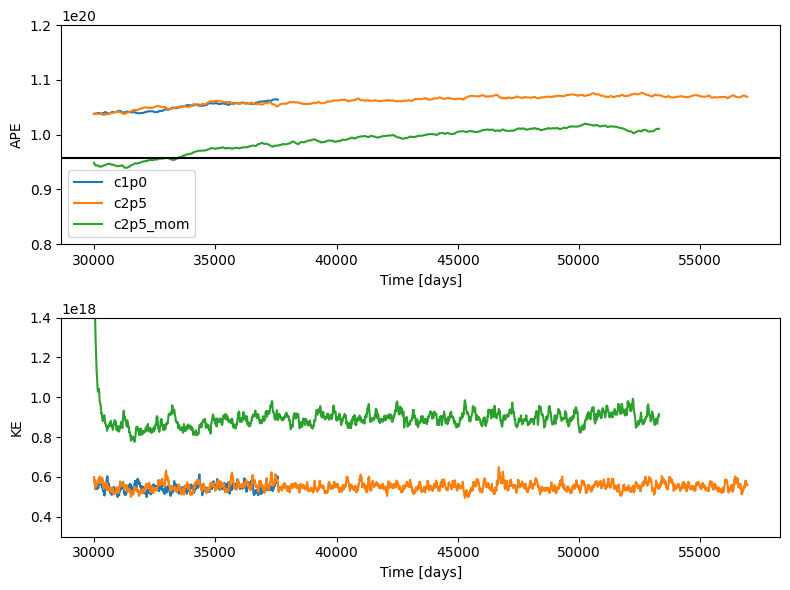

In [7]:
plt.figure(figsize=(8,6))

for exp in exp_list:
    plt.subplot(2,1,1)
    os_dic[exp].APE.sum('Interface').plot(label=exp)
    
    plt.subplot(2,1,2)
    os_dic[exp].KE.sum('Layer').plot(label=exp)

plt.subplot(2,1,1)
plt.axhline(y=0.958e+20, color='k')
plt.ylim([8e19, 12e19])


plt.tight_layout()
plt.legend(loc='lower left')

plt.subplot(2,1,2)
plt.ylim([3e17, 1.4e+18])

### Bulk statistics

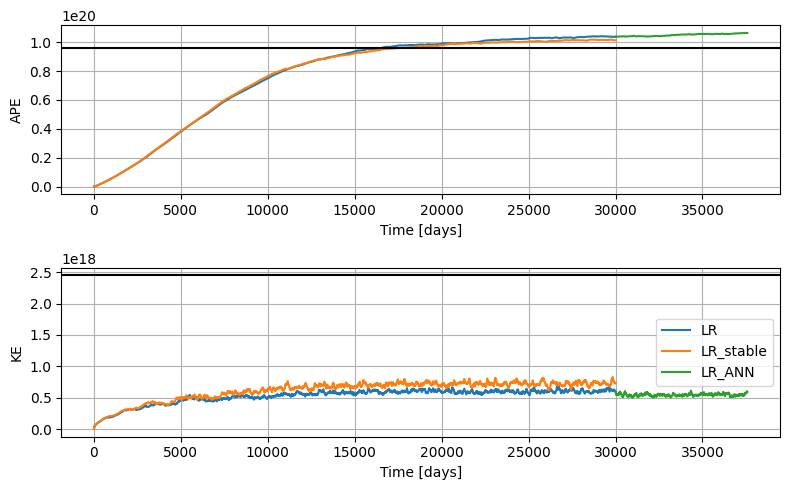

In [17]:
plt.figure(figsize=(8,5))

plt.subplot(2,1,1)
os_LR.APE.sum('Interface').plot(label='LR')
os_LR_stable.APE.sum('Interface').plot(label='LR_stable')
#os_LR_ANN_old.APE.sum('Interface').plot(label='LR_ANN_start')
os_LR_ANN.APE.sum('Interface').plot(label='LR_ANN')
plt.axhline(y=0.958e+20, color='k')
#plt.xlim(0, 30e3)
plt.grid()

plt.subplot(2,1,2)
os_LR.KE.sum('Layer').plot(label='LR')
os_LR_stable.KE.sum('Layer').plot(label='LR_stable')
#os_LR_ANN_old.KE.sum('Layer').plot(label='LR_ANN_old')
os_LR_ANN.KE.sum('Layer').plot(label='LR_ANN')
plt.axhline(y=2.45e+18, color='k')
#plt.xlim(0, 30e3)
plt.legend()
plt.grid()

plt.tight_layout()

### Speed plots

In [21]:
import xgcm
def KE_avg(ds_snapshots):
    grid = xgcm.Grid(ds_snapshots, coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
        'Z': {'center': 'zl', 'outer': 'zi'}
    }, periodic=['X'])
    KE = ((grid.interp(ds_snapshots.u**2,'X') + grid.interp(ds_snapshots.v**2,'Y', boundary='extend'))
          *ds_snapshots.h ) / 2
    KE = KE.sum(dim=['zl'])
    return KE

In [22]:
KE_HR = KE_avg(ds_HR_snapshots.isel(time=-1))
KE_LR_stable = KE_avg(ds_LR_stable_snapshots.isel(time=-1))
KE_LR = KE_avg(ds_LR_snapshots.isel(time=-1))
KE_LR_ANN = KE_avg(ds_LR_ANN_snapshots.isel(time=-1))

In [23]:
KE_HR.load();
KE_LR_stable.load();
KE_LR.load();
KE_LR_ANN.load();

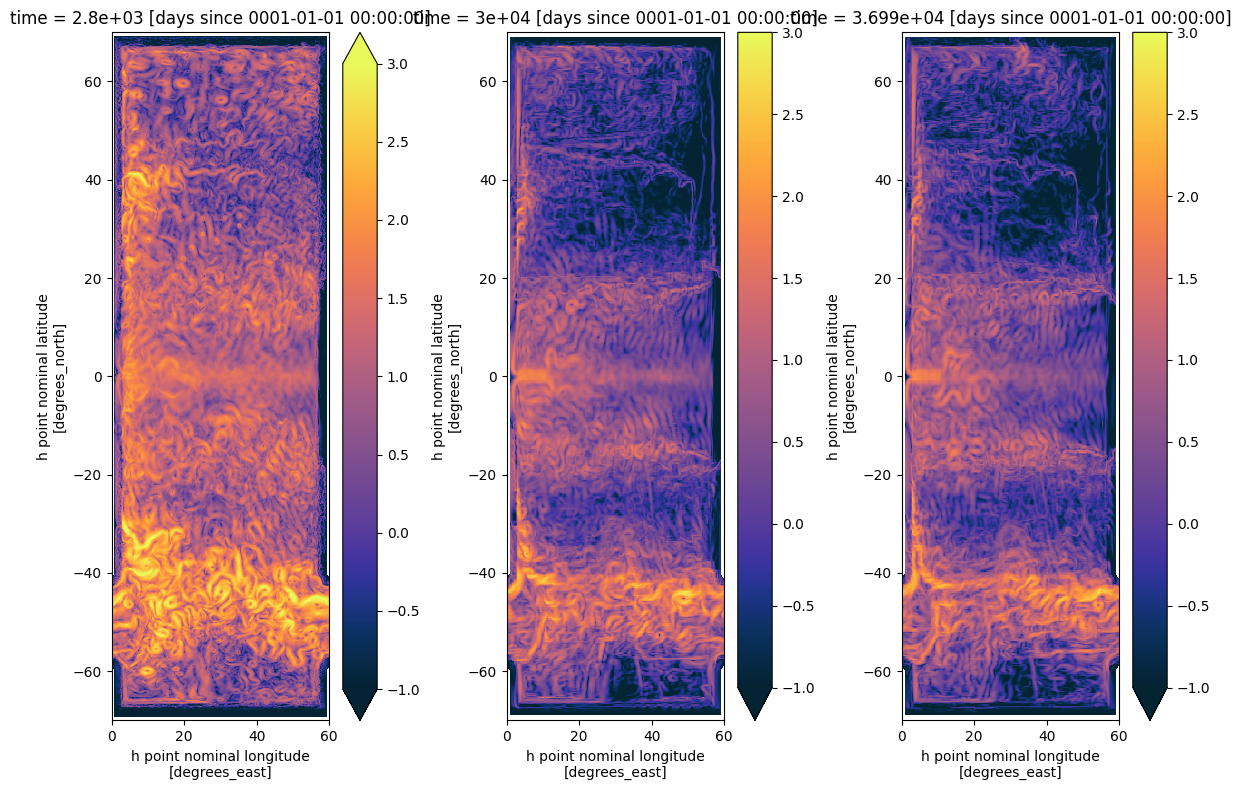

In [25]:
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
np.log10(KE_HR).plot(vmin=-1,vmax=3, cmap='cmo.thermal')

plt.subplot(1,3,2)
np.log10(KE_LR).plot(vmin=-1,vmax=3, cmap='cmo.thermal')

plt.subplot(1,3,3)
np.log10(KE_LR_ANN).plot(vmin=-1,vmax=3, cmap='cmo.thermal')

plt.tight_layout()


### Contrast the intefaces

In [26]:
LR_e = ds_LR.e.mean(dim='time')

factor = len(ds_HR.xh) // len(ds_LR.xh)
HR_e = ds_HR.e.coarsen({'xh': factor, 'yh': factor}).mean().interp(xh=ds_LR.xh, yh=ds_LR.yh).mean(dim='time')

LR_ANN_e = ds_LR_ANN.e.mean(dim='time')

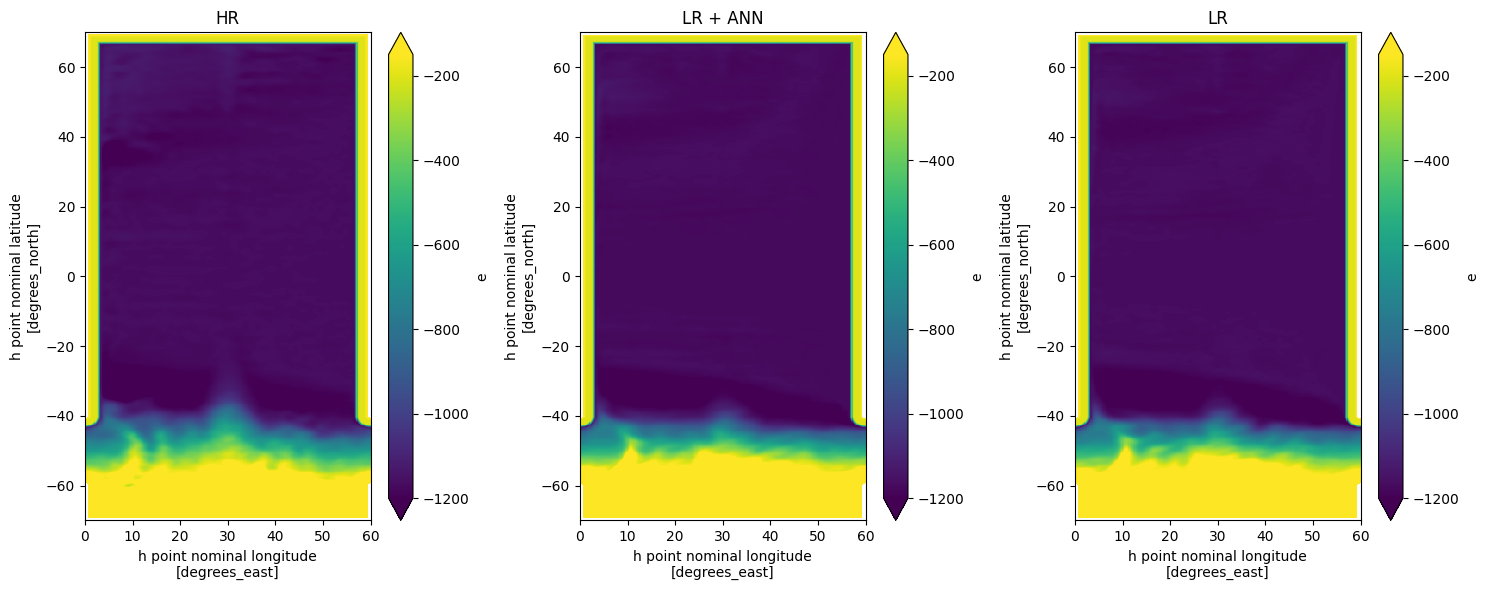

In [27]:
plt.figure(figsize=(15,6))

vmin=-1200
vmax= -150
plt.subplot(1,3,1)
HR_e.isel(zi = 8).plot(vmin=vmin, vmax=vmax)
plt.title('HR')

plt.subplot(1,3,2)
LR_ANN_e.isel(zi = 8).plot(vmin=vmin, vmax=vmax)
plt.title('LR + ANN')

plt.subplot(1,3,3)  
LR_e.isel(zi = 8).plot(vmin=vmin, vmax=vmax)
plt.title('LR')

plt.tight_layout()

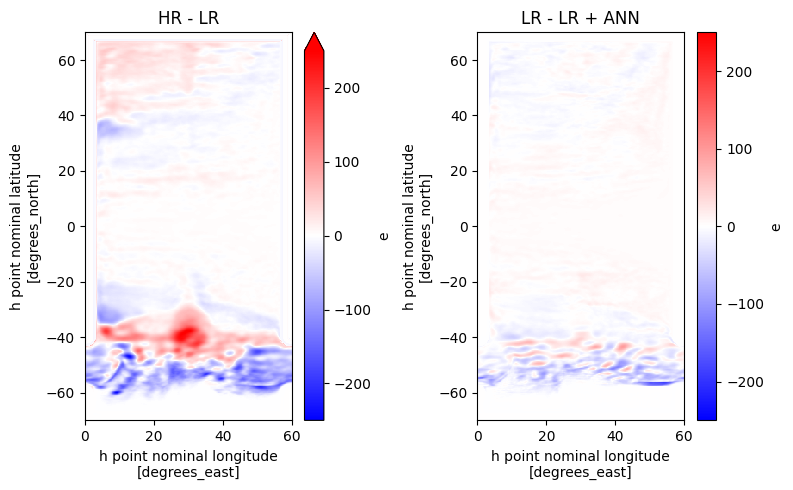

In [28]:
plt.figure(figsize=(8,5))


plt.subplot(1,2,1)
(HR_e - LR_e).isel(zi = 8).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(LR_e - LR_ANN_e).isel(zi = 8).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.tight_layout()

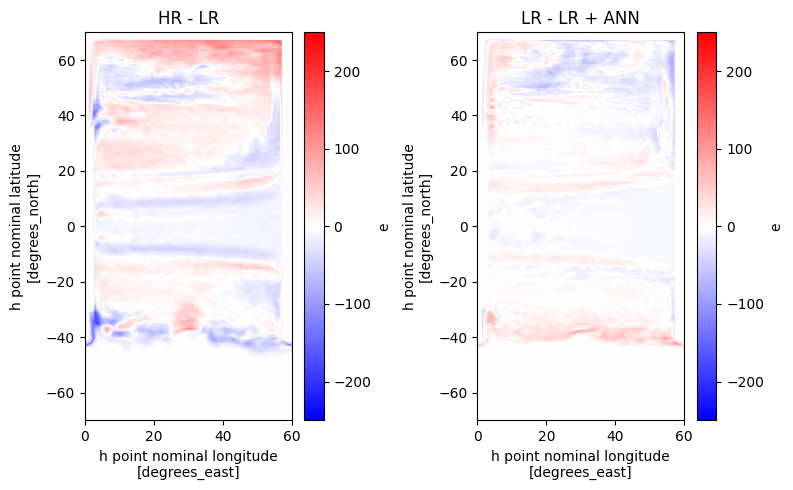

In [29]:
plt.figure(figsize=(8,5))

zi_index = 4  # specify the index of the vertical level you want to plot
plt.subplot(1,2,1)
(HR_e - LR_e).isel(zi = zi_index).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(LR_e - LR_ANN_e).isel(zi = zi_index).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.tight_layout()

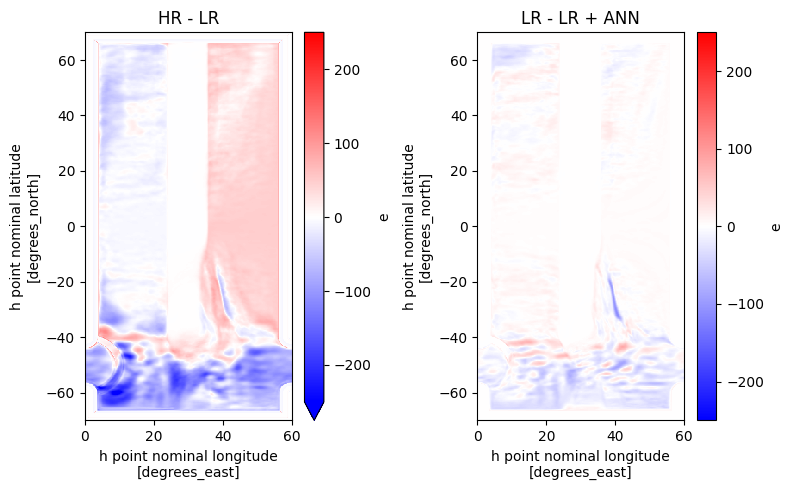

In [30]:
plt.figure(figsize=(8,5))

zi_index = 12  # specify the index of the vertical level you want to plot
plt.subplot(1,2,1)
(HR_e - LR_e).isel(zi = zi_index).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('HR - LR')

plt.subplot(1,2,2)  
(LR_e - LR_ANN_e).isel(zi = zi_index).plot(vmin=-250, vmax=250, cmap='bwr')
plt.title('LR - LR + ANN')

plt.tight_layout()

In [31]:
def rmse(hires, lores, av_dims=['xh','yh']):
    error = (lores - hires)
    if 'zi' in error.dims:
        error = error.isel(zi=slice(0,15))
    if av_dims is not None:
        RMSE = np.sqrt((error**2).mean(av_dims)) # RMSE in metres
    else:
        RMSE = np.sqrt((error**2)) # RMSE in metres
    return RMSE#round(float(RMSE),3)

In [32]:
RMSE_LR = rmse(HR_e, LR_e)
RMSE_LR.load();
RMSE_LR_ANN = rmse(HR_e, LR_ANN_e)
RMSE_LR_ANN.load();

Text(0.5, 0, 'RMSE of e [m]')

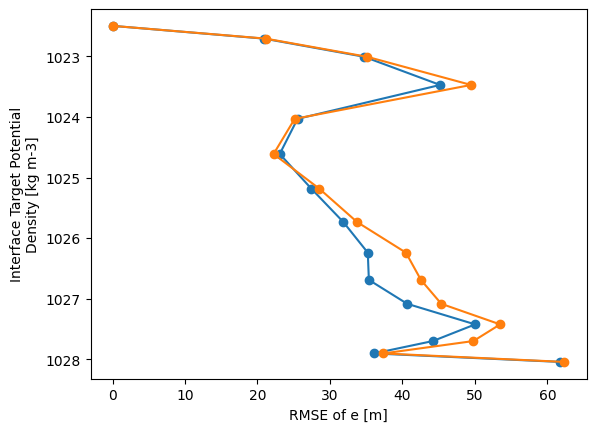

In [33]:
RMSE_LR.plot(y='zi',marker='o')
RMSE_LR_ANN.plot(y='zi',marker='o')
plt.gca().invert_yaxis()
plt.xlabel('RMSE of e [m]')

In [34]:
RMSE_LR_xav = rmse(HR_e, LR_e, av_dims=['xh'])
RMSE_LR_xav.load();
RMSE_LR_ANN_xav = rmse(HR_e, LR_ANN_e, av_dims=['xh'])
RMSE_LR_ANN_xav.load();

In [35]:
RMSE_LR_noav = rmse(HR_e, LR_e, av_dims=None)
RMSE_LR_noav.load();
RMSE_LR_ANN_noav = rmse(HR_e, LR_ANN_e, av_dims=None)
RMSE_LR_ANN_noav.load();

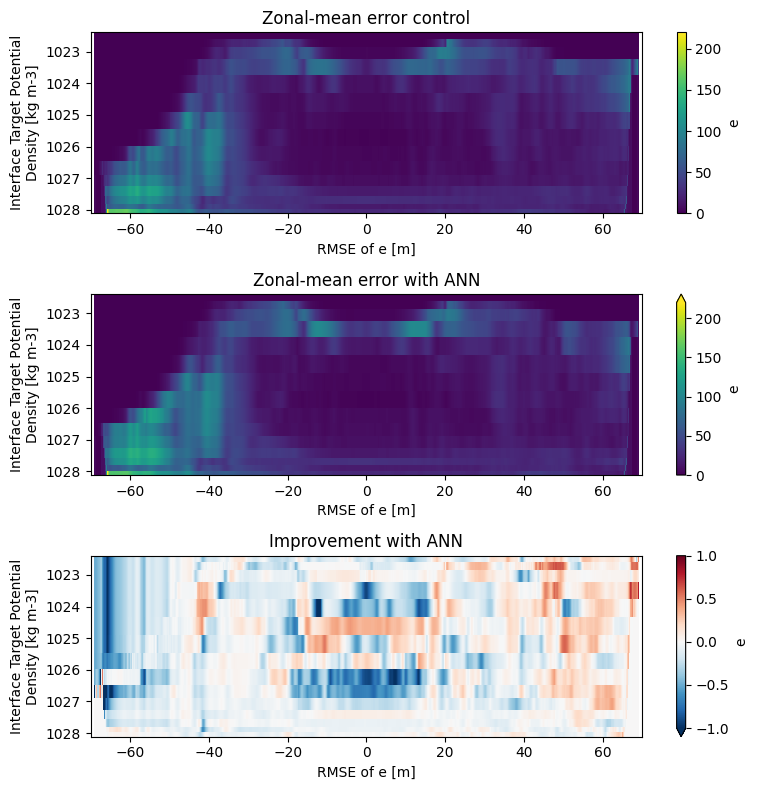

In [36]:
plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
RMSE_LR_xav.plot(y='zi',vmin=0,vmax=220)
plt.gca().invert_yaxis()
plt.xlabel('RMSE of e [m]')
plt.title('Zonal-mean error control')

plt.subplot(3,1,2)
RMSE_LR_ANN_xav.plot(y='zi', vmin=0,vmax=220)
plt.gca().invert_yaxis()
plt.xlabel('RMSE of e [m]')
plt.title('Zonal-mean error with ANN')

plt.subplot(3,1,3)
((RMSE_LR_xav - RMSE_LR_ANN_xav)/RMSE_LR_xav).plot(y='zi', vmin=-1,vmax=1, cmap='RdBu_r')
plt.gca().invert_yaxis()
plt.xlabel('RMSE of e [m]')
plt.title('Improvement with ANN')

plt.tight_layout()

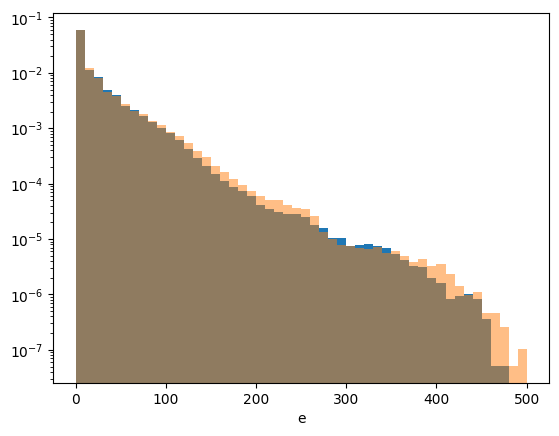

In [37]:
RMSE_LR_noav.plot.hist(bins=np.linspace(0,500,51), density=True);
RMSE_LR_ANN_noav.plot.hist(bins=np.linspace(0,500,51), alpha=0.5, density=True);
plt.yscale('log')

In [5]:
from functools import cache
@cache
def interface(exp='R4-long/bare', exp_path=None, lon=0, layer=None):
    if exp_path is None:
        base_path = '/scratch/pp2681/mom6/Neverworld2/simulations'
        if exp=='R32':
            ds = xr.open_mfdataset(f'{base_path}/R32/longmean*.nc', decode_times=False)
        else:
            try:
                ds = xr.open_dataset(f'{base_path}/{exp}/output/longmean_00029050.nc', decode_times=False)
            except:
                print('Experiment does not exist')
    else:
        if exp=='R32':
            ds = xr.open_mfdataset(exp_path+'longmean_00029050.nc', decode_times=False)
        else:
            ds = xr.open_dataset(exp_path+'longmean_00029050.nc', decode_times=False)
                                                                                                                                                
    e = ds.e
    
    if lon is not None:
        # lon=0,15,30,45
        if lon == 0:
            e = e.isel(xh=0)
        else:
            e = e.interp(xh=lon)
    
    if layer is not None:
        # layer = 0 is ssh
        e = e.isel(zi=layer)

    return e.mean('time').compute()

In [6]:
def interfaces(exp='R2-long/bare-stable', exp_path='/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/', lon=0, layer=None, lat_max=None):
    '''
    Simple wrapper returning hires and lores interfaces
    '''
    hires = interface('R32', lon=lon, layer=layer).sel(yh=slice(None,lat_max))
    lores = interface(exp,  exp_path=exp_path, lon=lon, layer=layer).sel(yh=slice(None,lat_max))

    if lon is None:
        factor = len(hires.xh) // len(lores.xh)
        return hires.coarsen({'xh': factor, 'yh': factor}).mean().interp(xh=lores.xh, yh=lores.yh), lores
    elif layer is None:
        return hires.interp(yh=lores.yh), lores
    else:
        print('Not implemented')
        

def rmse(hires, lores):
    error = (lores - hires)
    if 'zi' in error.dims:
        error = error.isel(zi=slice(0,15))
    RMSE = np.sqrt((error**2).mean()) # RMSE in metres
    return round(float(RMSE),3)

In [13]:
def rmse_upper(hires, lores):
    error = (lores.where(lores>-1000) - hires.where(hires>-1000))
    if 'zi' in error.dims:
        error = error.isel(zi=slice(0,15))
    RMSE = np.sqrt((error**2).mean()) # RMSE in metres
    return round(float(RMSE),3)

In [15]:
def plot_interfaces(hires, lores, print_RMSE=True):
    for zi in range(15):
        lores.isel(zi=zi).plot(ls='--', color='blue', lw=2)
        hires.isel(zi=zi).plot(ls='-', color='k', lw=2, alpha=0.5)
    hires.isel(zi=-1).plot(color='k') # show bathymetry 
    
    if print_RMSE:
        RMSE = rmse_upper(hires,lores)
        plt.text(0.7,0.1,'RMSE=\n'+"{:.1f}".format(RMSE)+'$\,\mathrm{m}$', fontsize=15, transform = plt.gca().transAxes)
    plt.xlabel('Latitude')
    plt.yticks(np.arange(-4000,1000,1000), np.arange(4000,-1000,-1000))
    plt.ylabel('Depth [m]')
    plt.title('')

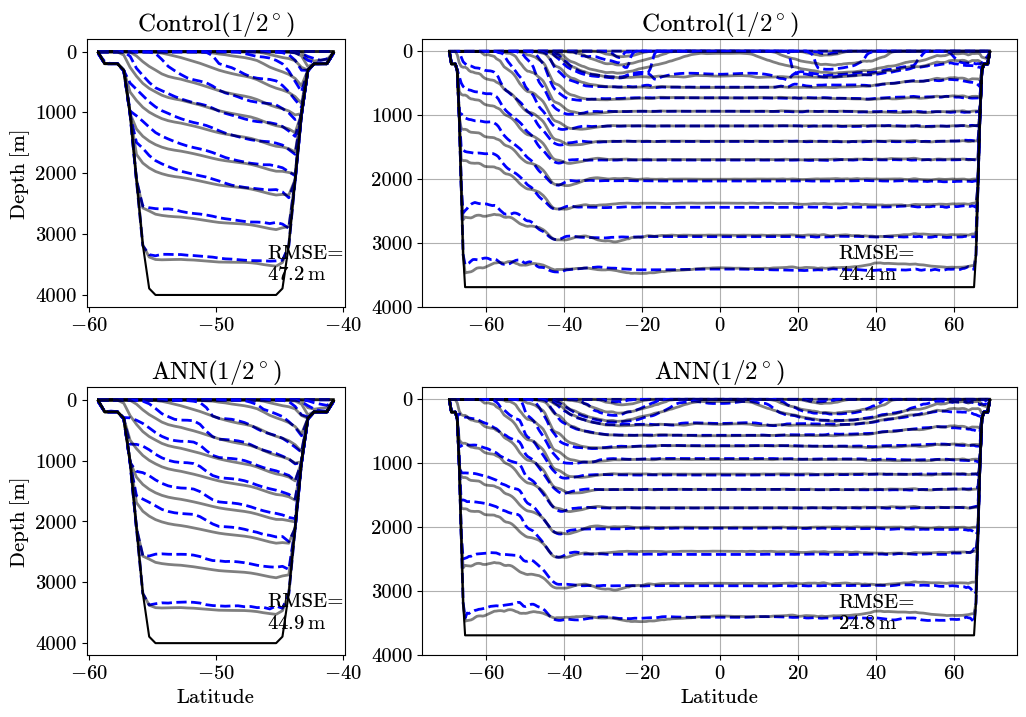

In [16]:
from matplotlib import gridspec
default_rcParams({'font.size': 15})
fig = plt.figure(figsize=(12,8))
gs = gridspec.GridSpec(2, 3, figure=fig, wspace=0.3, hspace=0.3)

kw = {'lon': 0, 'lat_max': None}

plt.sca(fig.add_subplot(gs[0, 0]))
plot_interfaces(*interfaces(exp='R2-long/bare-stable', exp_path='/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/', **kw))
plt.title('Control($1/2^\circ$)')
plt.xlabel('')

plt.sca(fig.add_subplot(gs[1, 0]))
plot_interfaces(*interfaces(exp='R2-WENO', exp_path='/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/test_20Dec_ANN/', **kw))
plt.title('ANN($1/2^\circ$)')

kw = {'lon': 45, 'lat_max': None}
plt.sca(fig.add_subplot(gs[0, 1:]))
plot_interfaces(*interfaces(exp='R2-long/bare-stable', exp_path='/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/', **kw))
plt.title('Control($1/2^\circ$)')
plt.ylabel('')
plt.xlabel('')
plt.grid()

plt.sca(fig.add_subplot(gs[1, 1:]))
plot_interfaces(*interfaces(exp='R2-WENO', exp_path='/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/test_20Dec_ANN/', **kw))
plt.title('ANN($1/2^\circ$)')
plt.ylabel('')
plt.grid()


plt.tight_layout()
#plt.savefig('/home/pp2681/MOM6-examples/src/MOM6/experiments/ANN-Results/notebooks-paper/figures/interfaces_lon_0_lon_45_NW2-upd.pdf')

In [17]:
def plot_interfaces(hires, lores, print_RMSE=True):
    for zi in range(15):
        lores.isel(zi=zi).plot(ls='-', color='blue', lw=2, label='ANN')
        hires.isel(zi=zi).plot(ls='-', color='red', lw=2, alpha=0.9, label='Control')
    hires.isel(zi=-1).plot(color='k') # show bathymetry 
    
    if print_RMSE:
        RMSE = rmse(hires,lores)
        plt.text(0.7,0.1,'RMSE=\n'+"{:.1f}".format(RMSE)+'$\,\mathrm{m}$', fontsize=15, transform = plt.gca().transAxes)
    #plt.legend()
    plt.xlabel('Latitude')
    plt.yticks(np.arange(-4000,1000,1000), np.arange(4000,-1000,-1000))
    plt.ylabel('Depth [m]')
    plt.title('')

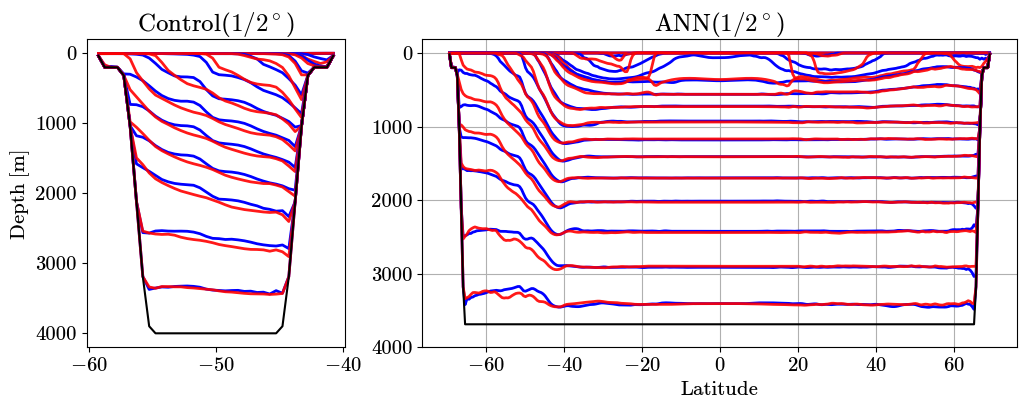

In [26]:
from matplotlib import gridspec
default_rcParams({'font.size': 15})
fig = plt.figure(figsize=(12,4))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3, hspace=0.3)


kw = {'lon': 0, 'lat_max': None}
_, control = interfaces(exp='R2-long/bare-stable', 
                            exp_path='/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/', **kw)
_, ANN = interfaces(exp='R2-WENO', exp_path='/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/test_20Dec_ANN/', **kw)

plt.sca(fig.add_subplot(gs[0]))
plot_interfaces(control, ANN,
                print_RMSE=False)
plt.title('Control($1/2^\circ$)')
plt.xlabel('')


kw = {'lon': 45, 'lat_max': None}
_, control = interfaces(exp='R2-long/bare-stable', 
                            exp_path='/scratch/pp2681/mom6/Neverworld2/simulations/R2-long/bare-stable/output/', **kw)
_, ANN = interfaces(exp='R2-WENO', exp_path='/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/test_20Dec_ANN/', **kw)


plt.sca(fig.add_subplot(gs[1:]))
plot_interfaces(control, ANN,
                print_RMSE=False)
plt.title('ANN($1/2^\circ$)')
plt.ylabel('')
plt.grid()


plt.tight_layout()
#plt.savefig('/home/pp2681/MOM6-examples/src/MOM6/experiments/ANN-Results/notebooks-paper/figures/interfaces_lon_0_lon_45_NW2-upd.pdf')